In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt


In [2]:
# 14 fearture, 1 label, 1025 samples
# target sẽ phân lại thành 0, 1
# Phân tích dữ liệu thô để quan sát

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


# Đọc file CSV và đặt tên cho các cột
df = pd.read_csv('heart.csv')
df.columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 
              'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Ánh xạ giá trị cột 'target'
df['target'] = df['target'].map({0: 0, 1: 1, 2: 1, 3: 1, 4: 1})
# Xử lý NaN cho cột 'thal' bằng Random Forest
'''
# Trong trường hợp có nhiều hàng chứa NaN sẽ tiến hành xử lý bằng random forest, các bước như sau:
# Tách DataFrame thành hai phần train_data: chứa các hàng có giá trị hợp lệ, test_data: chứa các hàng có giá trị NaN.

# Hàm xử lý mẫu cho từng cột
def fill_missing_values(df, column):
    # Chia dữ liệu thành phần không NaN (để train) và NaN (để dự đoán)
    train_data = df[df[column].notna()]
    test_data = df[df[column].isna()]
    
    # Nếu không có dữ liệu NaN trong cột, bỏ qua bước dự đoán
    if test_data.empty:
        return df
    
    # Tách đặc trưng và nhãn
    X_train = train_data.drop(columns=[column])
    y_train = train_data[column]
    
    # Tạo mô hình Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    # Dự đoán các giá trị NaN
    X_test = test_data.drop(columns=[column])
    predicted = rf.predict(X_test)
    
    # Điền các giá trị dự đoán vào cột
    df.loc[df[column].isna(), column] = predicted
    
    return df

# Gọi hàm xử lý cho các cột 'thal', 'ca', 'age'
df = fill_missing_values(df, 'thal')
df = fill_missing_values(df, 'ca')
df = fill_missing_values(df, 'age')
df = fill_missing_values(df, 'sex')
df = fill_missing_values(df, 'cp')
df = fill_missing_values(df, 'trestbps')
df = fill_missing_values(df, 'chol')
df = fill_missing_values(df, 'fbs')
df = fill_missing_values(df, 'restecg')
df = fill_missing_values(df, 'thalach')
df = fill_missing_values(df, 'exang')
df = fill_missing_values(df, 'oldpeak')
df = fill_missing_values(df, 'slope')


# Kiểm tra lại các giá trị NaN
print(df.isna().sum())
'''
# Chuyển đổi tất cả các cột sang kiểu số. Tham số errors='coerce' chỉ định rằng nếu không thể chuyển đổi một giá trị, nó sẽ trở thành NaN.
df = df.apply(pd.to_numeric, errors='coerce')
plt.show()







In [3]:
# Kiểm tra giá trị NaN trong dataset
nan_counts = df.isna().sum()
print(nan_counts)
if nan_counts.sum() > 0:
    print("Có giá trị NaN trong DataFrame.")
else:
    print("Không có giá trị NaN trong DataFrame.")

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Không có giá trị NaN trong DataFrame.


In [4]:
'''
Sử dụng khi có NaN
# Hiển thị các hàng chứa giá trị NaN
nan_rows = df[df.isna().any(axis=1)]
print("Các hàng chứa giá trị NaN:")
print(nan_rows)
'''

'\nSử dụng khi có NaN\n# Hiển thị các hàng chứa giá trị NaN\nnan_rows = df[df.isna().any(axis=1)]\nprint("Các hàng chứa giá trị NaN:")\nprint(nan_rows)\n'

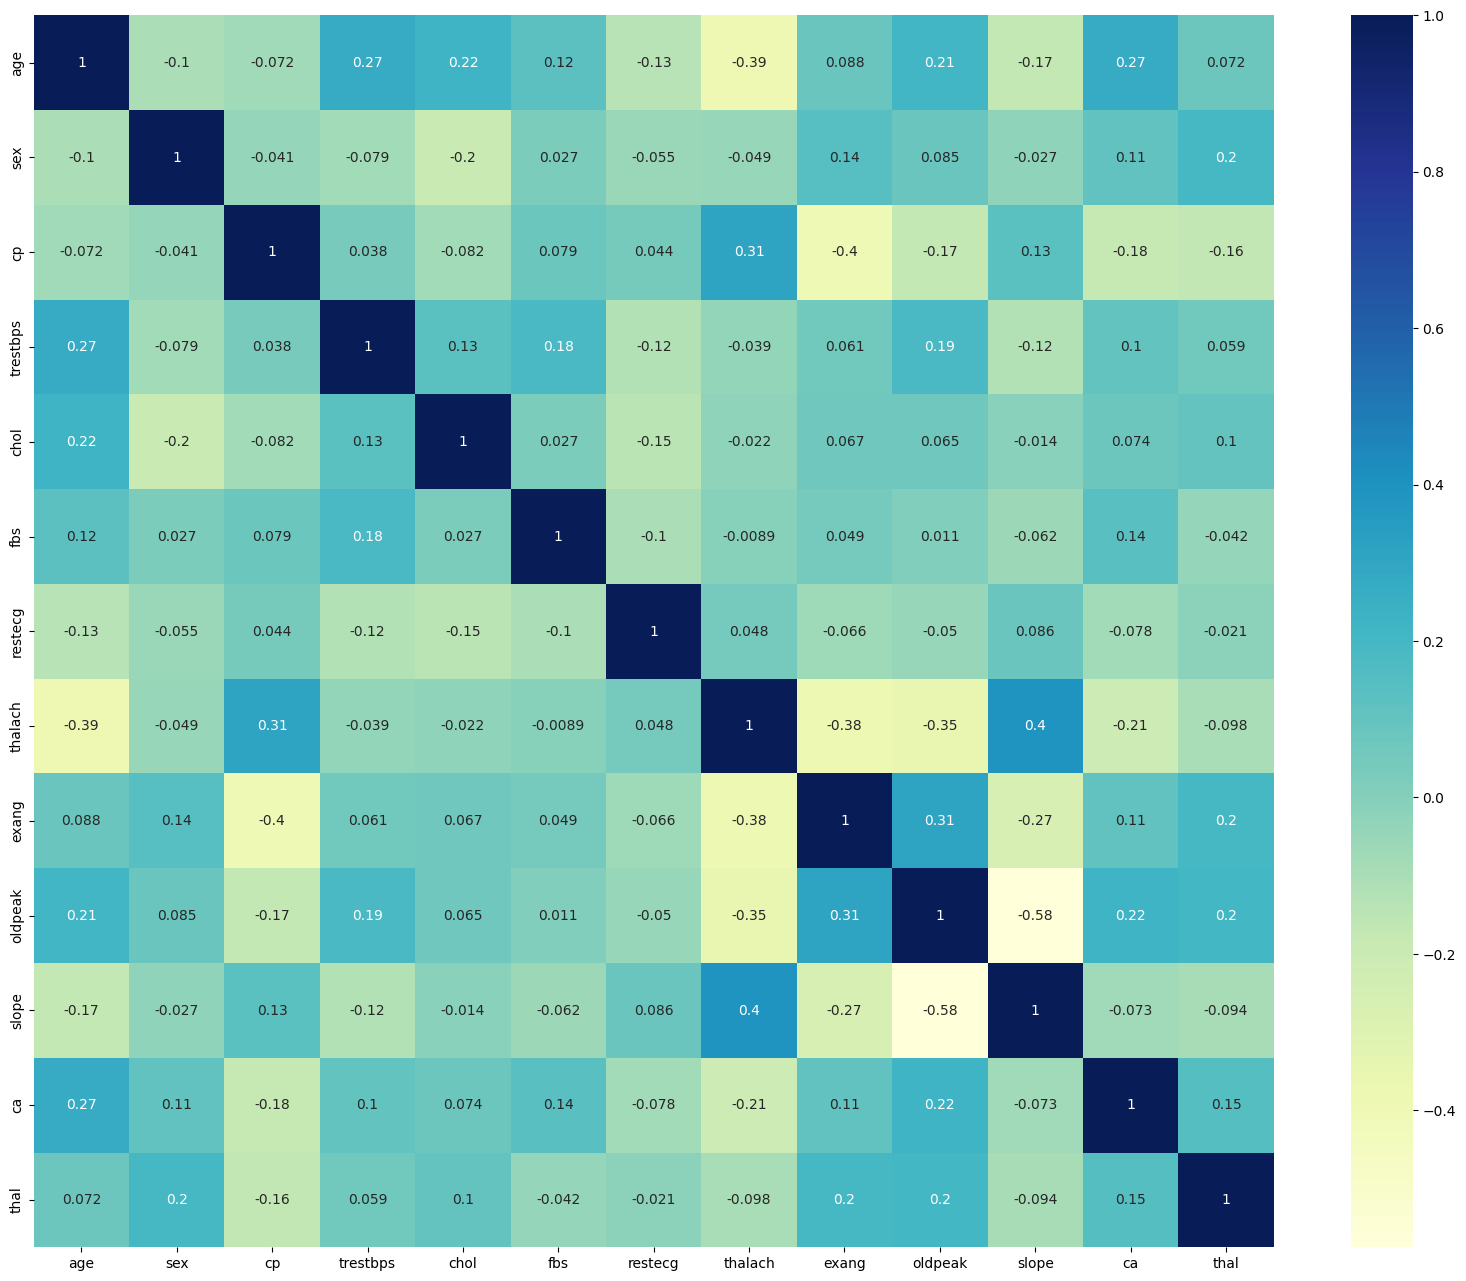

In [5]:
plt.figure(figsize=(20, 16))
sns.heatmap(df.drop('target', axis = 1). corr(), cmap="YlGnBu", annot = True)
plt.show()

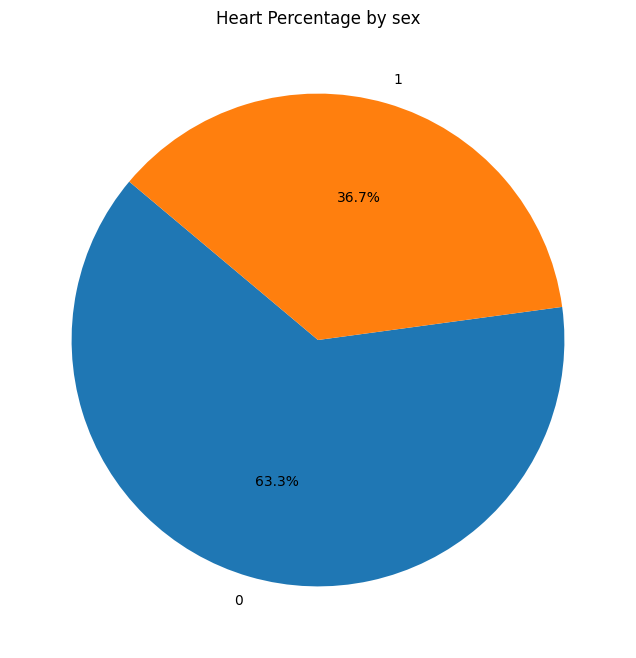

In [ ]:
ColumnsForCountPlot = ['sex']
for column in ColumnsForCountPlot:
    # Calculate the percentage of stroke occurrences for each category in the column
    heart_percentages = df.groupby(column)['target'].mean() * 100

    plt.figure(figsize=(8, 8))
    plt.pie(heart_percentages, labels=heart_percentages.index, autopct='%1.1f%%', startangle=140)
    plt.title(f'Heart Percentage by {column}')
    plt.show()


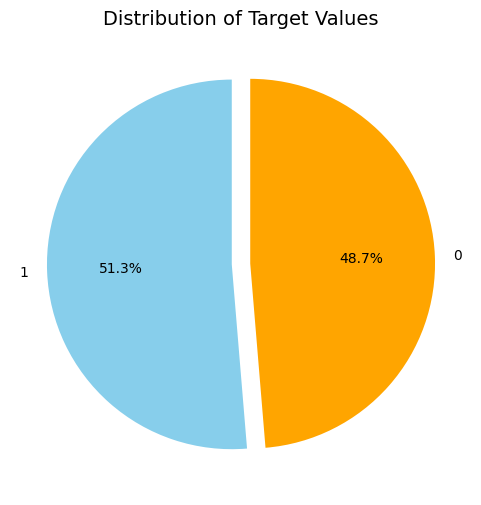

In [7]:
# Tính tần suất (số lượng) của từng giá trị trong cột 'target'
target_counts = df['target'].value_counts()

# Vẽ biểu đồ tròn
plt.figure(figsize=(6, 6))
plt.pie(
    target_counts, 
    labels=target_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['skyblue', 'orange'], 
    explode=[0.05] * len(target_counts)  # Tách nhẹ các phần
)

# Tùy chỉnh tiêu đề
plt.title('Distribution of Target Values', fontsize=14)
plt.show()

In [ ]:
#########################################   RandomForest  #############################################################

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Tách dữ liệu
X = df.iloc[:, :-1].values  # Các đặc trưng
y = df.iloc[:, -1].values    # Nhãn
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)


In [10]:

import lazypredict
from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)


100%|██████████| 31/31 [00:00<00:00, 36.26it/s]

[LightGBM] [Info] Number of positive: 423, number of negative: 397
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 820, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515854 -> initscore=0.063436
[LightGBM] [Info] Start training from score 0.063436
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
                               Accuracy  Balanced Accuracy  ROC A

In [11]:

# Khởi tạo mô hình Random Forest
classifier = RandomForestClassifier(random_state=42)

# Định nghĩa tham số để tối ưu hóa
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2'],  # Không sử dụng 'auto'
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'n_estimators': [50, 100, 200]
}

In [12]:
# Thiết lập GridSearchCV
grid_search = GridSearchCV(estimator=classifier, param_grid=param_grid, cv=5, n_jobs=-1, error_score='raise')

# Huấn luyện mô hình
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-validation Accuracy: 0.9817073170731707


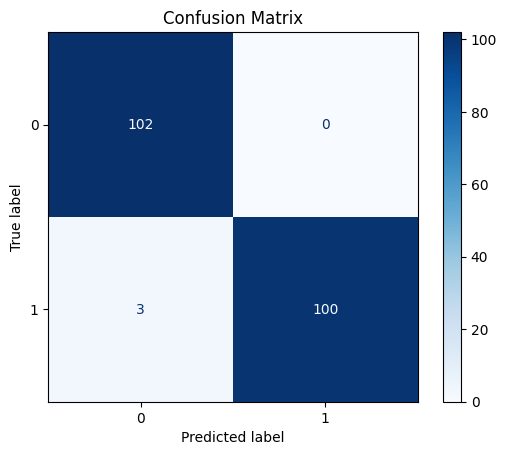

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

# Hiển thị ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [14]:
# Dự đoán và đánh giá mô hình với tham số tốt nhất
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Đánh giá mô hình
accuracy_for_test = accuracy_score(y_test, y_pred)
print('Accuracy for test set with best parameters = {:.2f}'.format(accuracy_for_test))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

# Optional: Confusion Matrix
confusion_mat = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:\n', confusion_mat)

Accuracy for test set with best parameters = 0.99

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205


Confusion Matrix:
 [[102   0]
 [  3 100]]


AUC = 1.00


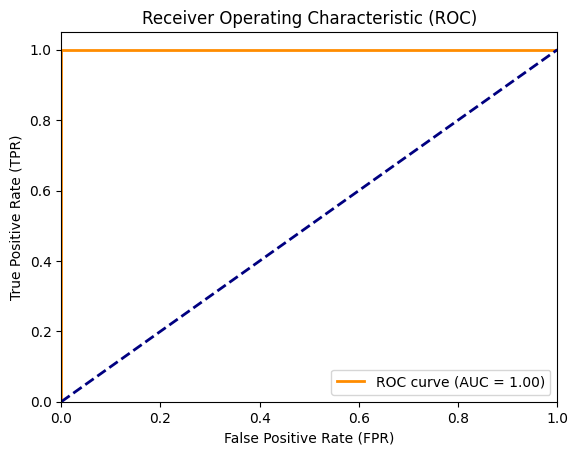

In [15]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Giả sử y_test là nhãn thực tế và y_pred_prob là xác suất dự đoán của mô hình (không phải nhãn)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]  # Lấy xác suất của lớp dương

# Tính toán ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Tính toán AUC
roc_auc = auc(fpr, tpr)
print('AUC = {:.2f}'.format(roc_auc))

# Vẽ đường ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Đường chéo thể hiện dự đoán ngẫu nhiên
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


In [16]:
import pickle
with open('heartV1.pkl','wb') as file:
    pickle.dump(grid_search, file)

import pickle
with open('heart.pkl','wb') as file:
    pickle.dump(grid_search, file)

#########################################   RandomForest  #############################################################

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Giả sử df là DataFrame của bạn
# Tách dữ liệu
X = df.iloc[:, :-1].values  # Các đặc trưng
y = df.iloc[:, -1].values   # Nhãn

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo mô hình Random Forest
classifier = RandomForestClassifier(random_state=42)

# Định nghĩa tham số để tối ưu hóa
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Thiết lập GridSearchCV
grid_search = GridSearchCV(estimator=classifier, param_grid=param_grid, 
                           scoring='accuracy', cv=5, verbose=2, n_jobs=-1)

# Huấn luyện mô hình
grid_search.fit(X_train, y_train)

# Xem kết quả
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Accuracy:", grid_search.best_score_)

# Dự đoán và đánh giá mô hình với tham số tốt nhất
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

# Đánh giá mô hình
accuracy_best = accuracy_score(y_test, y_pred_best)
print('Accuracy for test set with best parameters = {:.2f}'.format(accuracy_best))
print('\nClassification Report:\n', classification_report(y_test, y_pred_best))

